# Figure 1.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Dust density snapshots for Problem BA at grid resolution $512^2$.
Each row shows those from a single code (Section 2.2), and each column shows the simulation time in local orbital periods $T$.
In alphabetical order from top to bottom, upper and lower groups implement an average of $n_\mathrm{p} = 1$ particle per grid cell/point and a pressureless dust fluid, (Sections 2.1.2 and 2.1.3) respectively.
Radial $x$ and vertical $z$ coordinates are in units of the vertical gas scale height $H$.
The color scale at the bottom right shows the dust density $\rho_\mathrm{d}$ relative to the initially uniform gas density $\rho_\mathrm{g,0}$ and applies to all snapshots.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}

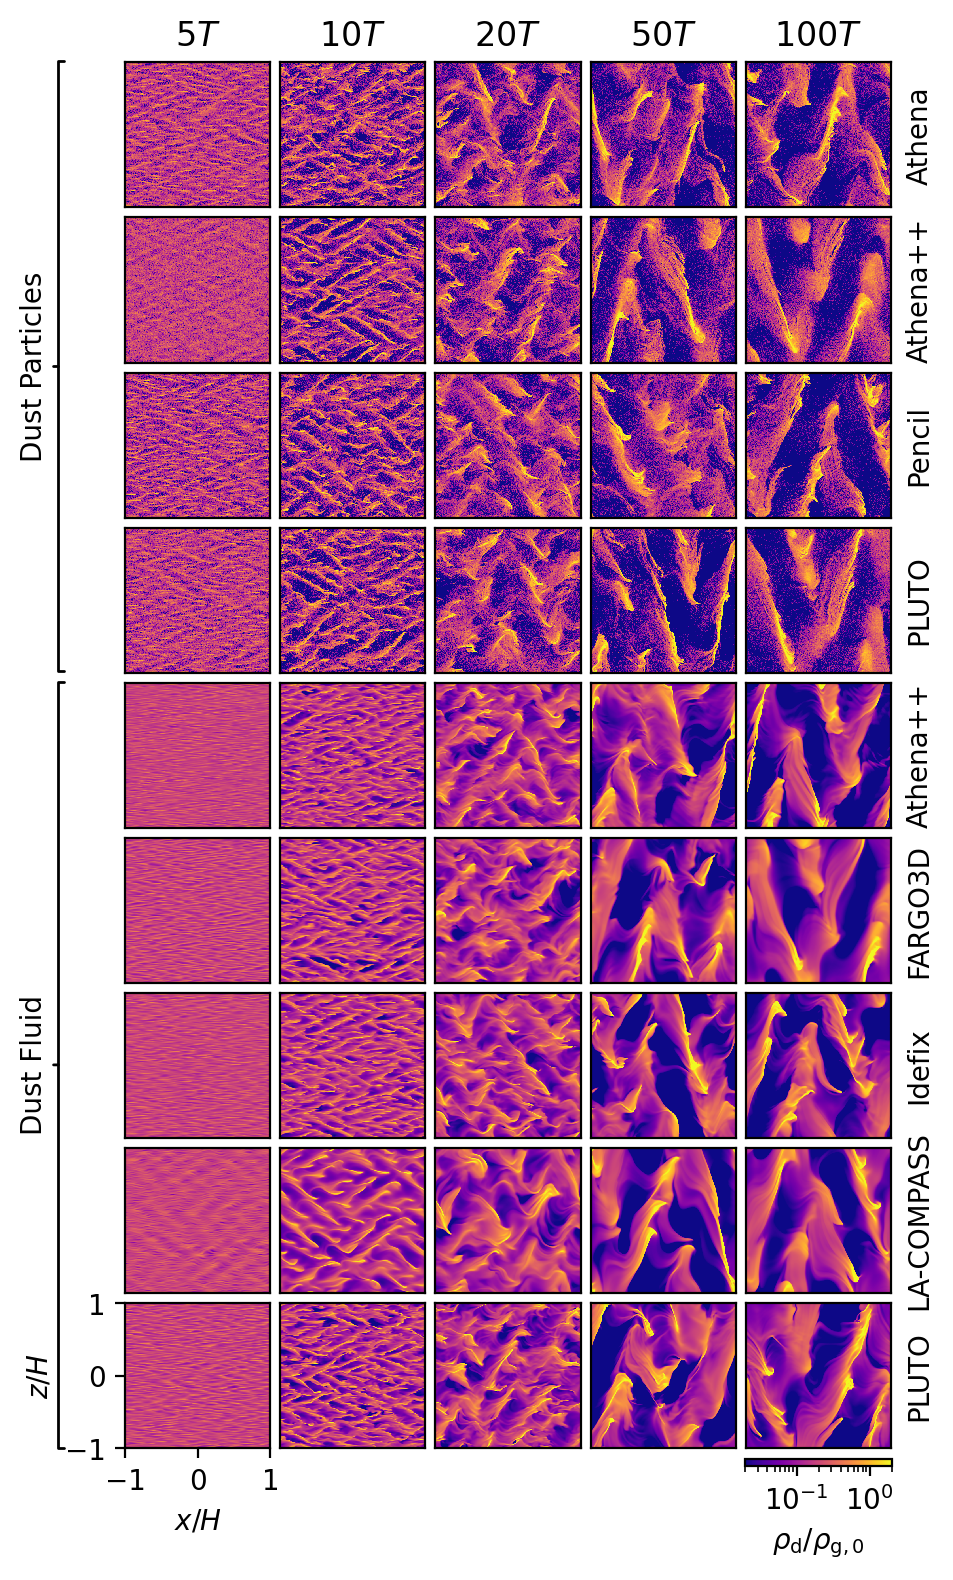

In [2]:
#===============================================================================
times = [5, 10, 20, 50, 100]
vmin, vmax = 2e-2, 2e0 # BA CDF(rhod) > 90%; CDF(rhod) < 1%
nrows, nfluid, nparticles = 0, 0, 0
for key, value in runs.items():
    for code in value['codes']:
        nrows += 1

# Plot
fig = plt.figure(figsize=(8, nrows), dpi=200)
ax_grid = AxesGrid(fig, 111, nrows_ncols=(nrows, len(times)), axes_pad=0.05,
                   share_all=True, label_mode='1')
j = 0
for key, value in runs.items():
    for code in value['codes']:
        path = f'{root}/{key}/{code}'
        row = j*len(times)
        for i, time in enumerate(times):
            if j == 0:
                ax_grid[i].set_title(rf'{time}$T$')
            if i == len(times)-1:
                ax_grid[row+i].text(1.1, 0.5, f'{code}', rotation='vertical',
                                    va='center',
                                    transform=ax_grid[row+i].transAxes)
            snapshot = np.load(f'{path}/{time}.npz')
            x = snapshot['x']
            z = snapshot['z']
            try:
                rhod = snapshot['rhod']
            except KeyError:
                print(code)
            clip = np.clip(rhod, vmin, vmax)
            # clip = rhod
            pcm = ax_grid[row+i].pcolormesh(x, z, clip, cmap='plasma',#'RdBu',
                                            rasterized=True,
                                            norm=colors.LogNorm(vmin=vmin,
                                                                vmax=vmax))
                                            # norm=colors.SymLogNorm(linthresh=0.1,
                                            #                        vmin=-vmax,
                                            #                        vmax=vmax))
            ax_grid[row+i].tick_params(bottom=False, left=False)
        j += 1

# Annotate groups
x_bracket = ax_grid[0].get_position().x0 + 0.1
y0 = 0.711
bracket = FancyArrowPatch((x_bracket, y0), (x_bracket+0.01, y0),
                          transform=fig.transFigure,
                          arrowstyle='-[, widthB=109.8, lengthB=2')
fig.patches.append(bracket)
fig.text(x_bracket, y0, "Dust Particles", va='center', ha='right',
         rotation='vertical')
y1 = 0.323
bracket = FancyArrowPatch((x_bracket, y1), (x_bracket+0.01, y1),
                          transform=fig.transFigure,
                          arrowstyle='-[, widthB=138, lengthB=2')
fig.patches.append(bracket)
fig.text(x_bracket, y1, "Dust Fluid", va='center', ha='right',
         rotation='vertical')

# Format plots
# fig.suptitle('Baronett, Lyra+ (submitted)', y=0.93)
x1 = ax_grid[-1].get_position().x1 - 0.116
plt.colorbar(pcm, orientation='horizontal', shrink=0.118, anchor=(x1, -0.088),
             label=r'$\rho_\mathrm{d}/\rho_\mathrm{g,0}$')
bot_left = len(ax_grid)-len(times)
ax_grid[bot_left].set(xlabel=r'$x/H$', ylabel=r'$z/H$')
ax_grid[bot_left].tick_params(bottom=True, left=True)